# Ho-Lee Model

The Ho-Lee model, introduced by Thomas Ho and Sang-Bin Lee in 1986, represents one of the earliest arbitrage-free models of the term structure of interest rates. Unlike earlier equilibrium models, the Ho-Lee framework explicitly incorporates the initial yield curve as an input, ensuring perfect calibration to market-observed bond prices. This model occupies a foundational position in the development of modern fixed-income derivative pricing.

## 1. Fundamental Assumptions

The Ho-Lee model is built upon a set of classical no-arbitrage assumptions:

* **Single Stochastic Factor:** The instantaneous short rate is the sole source of randomness in the economy.
* **Gaussian Dynamics:** The short rate evolves according to a Gaussian diffusion process, yielding analytically tractable solutions.
* **Arbitrage-Free Framework:** Bond prices are calibrated to eliminate arbitrage opportunities in the initial market.
* **Time-Dependent Drift:** The drift component is deterministic and calibrated to fit the initial term structure exactly.
* **Perfect Market Conditions:** Markets are assumed frictionless with continuous trading and no transaction costs.

## 2. Key Model Parameters

The Ho-Lee specification requires:

1. $r_t$: instantaneous short rate at time $t$.
2. $\theta(t)$: deterministic time-dependent drift function.
3. $\sigma$: constant volatility parameter.
4. $P(0,t)$: initial zero-coupon bond prices observed in the market.
5. $T - t$: time to maturity.

## 3. Mathematical Formulation

The Ho-Lee short-rate dynamics are governed by the stochastic differential equation:

$$
dr_t = \theta(t) \, dt + \sigma \, dW_t
$$

where $W_t$ denotes a standard Brownian motion under the risk-neutral measure. Unlike mean-reverting models, the Ho-Lee process exhibits a pure random walk behavior with a deterministic drift superimposed.

Key characteristics include:

* **No Mean Reversion:** The process exhibits a random walk structure without reversion to a long-run level.
* **Linear Drift:** $\theta(t)$ is an arbitrary deterministic function determined by calibration.
* **Constant Volatility:** $\sigma$ remains constant across time and states.

## 4. Analytical Bond Pricing

Under the Ho-Lee model, the zero-coupon bond price $P(t,T)$ admits a closed-form solution:

$$
P(t,T) = \frac{P(0,T)}{P(0,t)} \exp\left[ -r_t(T-t) - \frac{\sigma^2}{6}(T-t)^3 + \frac{\sigma^2}{2}(T-t)^2 t \right]
$$

Equivalently, the bond price can be expressed as:

$$
P(t,T) = \exp\left[ A(t,T) - B(t,T) r_t \right]
$$

with the affine components:

$$
B(t,T) = T - t
$$

and

$$
A(t,T) = \ln\frac{P(0,T)}{P(0,t)} - \frac{\sigma^2}{6}(T-t)^3
$$

The drift function $\theta(t)$ is calibrated to match the initial term structure through:

$$
\theta(t) = \frac{\partial \ln P(0,t)}{\partial t} + \sigma^2 t
$$

This calibration procedure ensures that model prices align exactly with observed market bond prices at time zero.

## 5. Interpretation and Practical Applications

The Ho-Lee model provides several advantages for practitioners:

* it delivers closed-form pricing formulas for bonds and certain interest-rate derivatives;
* it guarantees exact fit to the initial yield curve by construction;
* it simplifies numerical implementation in lattice-based approaches for derivative pricing;
* it serves as a pedagogical foundation for understanding arbitrage-free term structure models.

The model is particularly suited for pricing interest-rate options, including European swaptions and bond options, within a recombining trinomial or binomial tree framework.

## 6. Limitations and Extensions

The Ho-Lee model exhibits notable limitations:

* it permits negative short rates due to Gaussian assumptions, a theoretically undesirable feature;
* it lacks mean reversion, making long-horizon forecasts economically questionable;
* it relies on a single risk factor, neglecting multiple sources of yield curve uncertainty;
* constant volatility assumptions fail to capture state-dependent dynamics observed in markets.

These limitations motivated subsequent extensions, including the Hull-White model (with mean reversion) and multi-factor generalizations. Nevertheless, the Ho-Lee framework remains instrumental for understanding the mechanics of arbitrage-free modeling and continues to serve as a benchmark in fixed-income analytics.

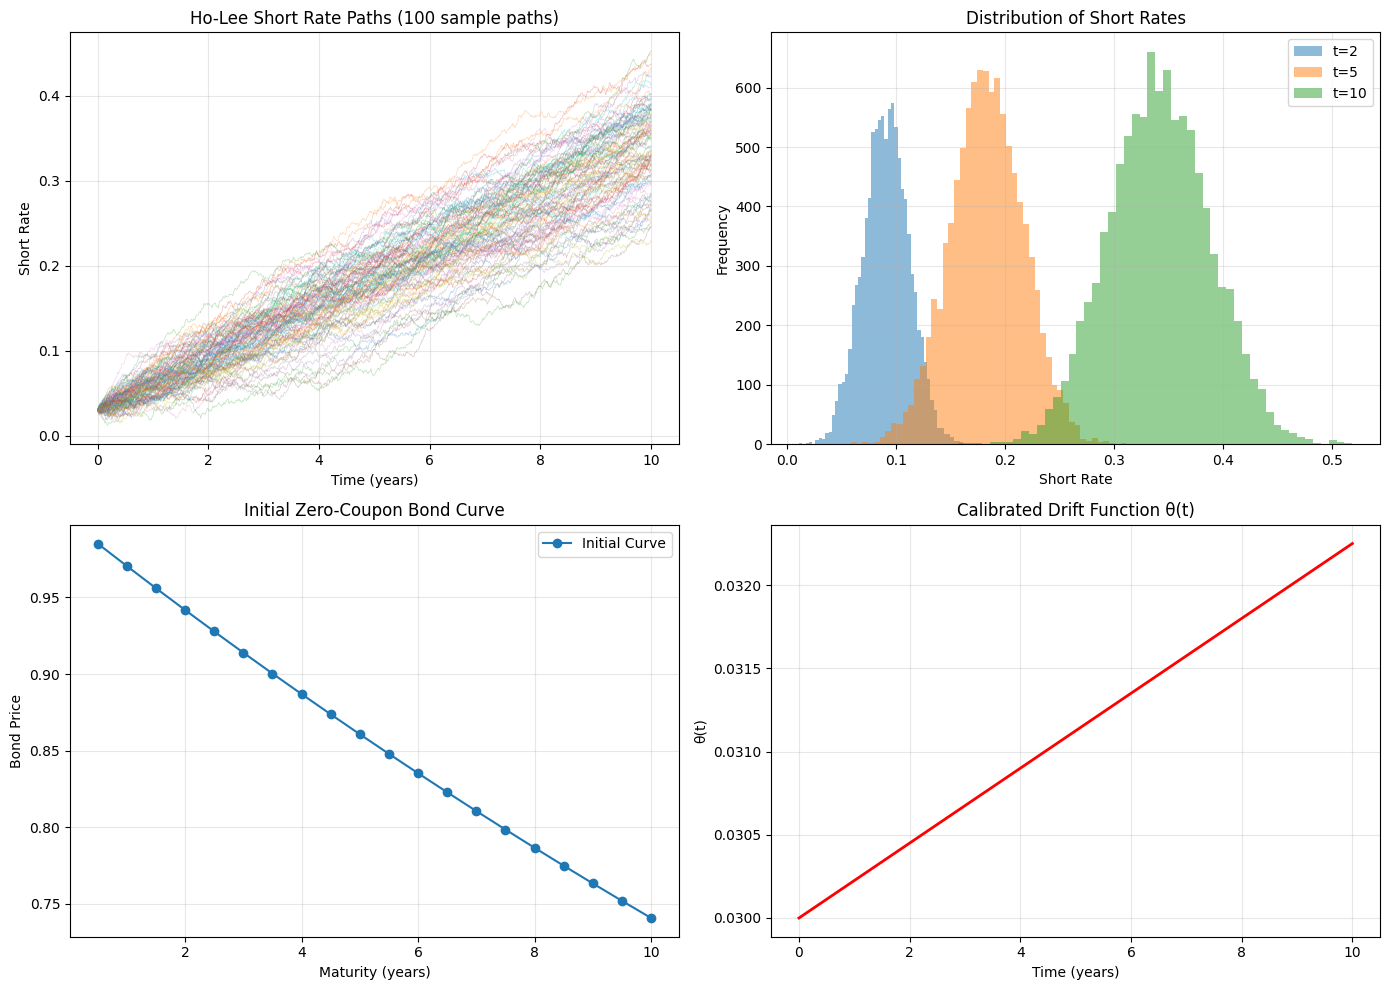


Bond Price Comparison (at t=0):
 Maturity (years)  Simulated Bond Price  Market Bond Price
                1                   1.0           0.970446
                3                   1.0           0.913931
                5                   1.0           0.860708
               10                   1.0           0.740818


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import pandas as pd

# Parameters
T_max = 10  # Maximum maturity
dt = 0.01   # Time step
sigma = 0.015  # Volatility
r0 = 0.03   # Initial short rate

# Initial yield curve (example: flat at 3%)
def P_market(t):
    """Market zero-coupon bond prices (flat curve at 3%)"""
    return np.exp(-0.03 * t)

def forward_rate(t, h=1e-5):
    """Initial forward rate curve"""
    return -(np.log(P_market(t + h)) - np.log(P_market(t))) / h

# Calibrate theta(t)
def theta(t):
    """Drift function calibrated to initial term structure"""
    f_t = forward_rate(t)
    return f_t + sigma**2 * t

# Bond pricing under Ho-Lee
def bond_price_hw(r_t, t, T, P_0T, P_0t):
    """Ho-Lee zero-coupon bond price"""
    B = T - t
    A = np.log(P_0T / P_0t) - (sigma**2 / 6) * B**3
    return np.exp(A - B * r_t)

# Monte Carlo simulation
num_paths = 10000
num_steps = int(T_max / dt)
times = np.linspace(0, T_max, num_steps + 1)
paths = np.zeros((num_paths, num_steps + 1))
paths[:, 0] = r0

np.random.seed(42)
dW = np.random.normal(0, np.sqrt(dt), (num_paths, num_steps))

for i in range(num_steps):
    t = times[i]
    paths[:, i+1] = paths[:, i] + theta(t) * dt + sigma * dW[:, i]

# Compute bond prices along paths
maturities = np.array([1, 3, 5, 10])
bond_prices = {}

for T in maturities:
    idx = int(T / dt)
    prices_at_T = []
    for path in paths:
        r_t = path[idx]
        P_0T = P_market(T)
        P_0t = P_market(times[idx])
        price = bond_price_hw(r_t, times[idx], T, P_0T, P_0t)
        prices_at_T.append(price)
    bond_prices[T] = np.mean(prices_at_T)

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Short rate paths
axes[0, 0].plot(times, paths[:100, :].T, alpha=0.3, linewidth=0.5)
axes[0, 0].set_xlabel('Time (years)')
axes[0, 0].set_ylabel('Short Rate')
axes[0, 0].set_title('Ho-Lee Short Rate Paths (100 sample paths)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Short rate distribution at different times
times_check = [2, 5, 10]
for t_check in times_check:
    idx = int(t_check / dt)
    axes[0, 1].hist(paths[:, idx], bins=50, alpha=0.5, label=f't={t_check}')
axes[0, 1].set_xlabel('Short Rate')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Short Rates')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Bond prices at different maturities
maturities_plot = np.linspace(0.5, 10, 20)
bond_prices_plot = [P_market(T) for T in maturities_plot]
axes[1, 0].plot(maturities_plot, bond_prices_plot, marker='o', label='Initial Curve')
axes[1, 0].set_xlabel('Maturity (years)')
axes[1, 0].set_ylabel('Bond Price')
axes[1, 0].set_title('Initial Zero-Coupon Bond Curve')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Plot 4: Theta function
theta_times = np.linspace(0, T_max, 100)
theta_values = [theta(t) for t in theta_times]
axes[1, 1].plot(theta_times, theta_values, linewidth=2, color='red')
axes[1, 1].set_xlabel('Time (years)')
axes[1, 1].set_ylabel('θ(t)')
axes[1, 1].set_title('Calibrated Drift Function θ(t)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    'Maturity (years)': list(bond_prices.keys()),
    'Simulated Bond Price': list(bond_prices.values()),
    'Market Bond Price': [P_market(T) for T in bond_prices.keys()]
})
print("\nBond Price Comparison (at t=0):")
print(summary.to_string(index=False))